In [1]:
# !pip install torch torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -q
# (On some platforms you may need platform-specific wheels; see https://pytorch-geometric.readthedocs.io/)

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

# --- Repro & device ---
seed = 42
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Data: Cora with normalized node features ---
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())
data = dataset[0].to(device)

# --- Model: 2-layer GAT (8 heads -> 8*8 hidden, then 1 head to num_classes) ---
class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads_1=8, heads_2=1, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads_1, dropout=dropout)
        # concat=True by default on GATConv, so output dim of layer1 is hidden_dim * heads_1
        self.gat2 = GATConv(hidden_dim * heads_1, out_dim, heads=heads_2,
                            concat=False, dropout=dropout)  # concat=False for final logits

    def forward(self, x, edge_index):
        print("x", x.shape)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x  # logits

model = GAT(
    in_dim=dataset.num_node_features,
    hidden_dim=8,
    out_dim=dataset.num_classes,
    heads_1=8,
    heads_2=1,
    dropout=0.6
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

def accuracy(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

best_val_acc = 0.0
best_state = None

for epoch in range(1, 401):
    # --- Train ---
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    # --- Eval ---
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        train_acc = accuracy(logits[data.train_mask], data.y[data.train_mask])
        val_acc = accuracy(logits[data.val_mask], data.y[data.val_mask])
        test_acc = accuracy(logits[data.test_mask], data.y[data.test_mask])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | loss {loss.item():.4f} | "
              f"train {train_acc:.3f} | val {val_acc:.3f} | test {test_acc:.3f}")

# --- Load best-by-val and report test ---
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    final_test_acc = accuracy(logits[data.test_mask], data.y[data.test_mask])
print(f"\nBest val acc: {best_val_acc:.3f} | Test acc (at best val): {final_test_acc:.3f}")


Processing...
Done!


x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
Epoch   1 | loss 1.9495 | train 0.250 | val 0.204 | test 0.200
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708, 1433])
x torch.Size([2708,

In [2]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

x      = np.array([-3,-2,-1,0,1,2,3], dtype=float)
actual = np.array([10,6,4,3,2,1,5], dtype=float)
pred   = np.array([5,4,7,8,5,2,1], dtype=float)

# interpolation of pred
pred_interp = interp1d(x, pred, kind='cubic', fill_value="extrapolate")

# objective: difference in variance around 0
def objective(k):
    x_scaled = x / k
    pred_scaled = pred_interp(x_scaled)
    pred_scaled *= actual.sum() / pred_scaled.sum()  # renormalize sum
    # minimize squared error vs actual
    return np.sum((pred_scaled - actual)**2)

res = minimize_scalar(objective, bounds=(0.5,3.0), method='bounded')
k_opt = res.x
print("Optimal stretch factor:", k_opt)

# final scaled predictions
x_scaled = x / k_opt
pred_final = pred_interp(x_scaled)
pred_final *= actual.sum() / pred_final.sum()
print(pred_final, "sum:", pred_final.sum())


Optimal stretch factor: 2.999995351492065
[4.39017221 4.87271695 5.10472582 5.01734278 4.57821377 3.90099276
 3.13583571] sum: 31.0


In [3]:
import torch.nn.utils.rnn as rnn_utils

In [4]:
import torch
from torch.nn.utils.rnn import pad_sequence

# Example: 3 sequences of different lengths
seq1 = torch.tensor([1, 2, 3])        # length 3
seq2 = torch.tensor([4, 5])           # length 2
seq3 = torch.tensor([6, 7, 8, 9])     # length 4

# Put them in a list
sequences = [seq1, seq2, seq3]

# Pad them
padded = pad_sequence(sequences, batch_first=True, padding_value=0)

print("Original sequences:")
for i, s in enumerate(sequences, 1):
    print(f"Seq{i}: {s.tolist()}")

print("\nPadded result (batch_first=True):")
print(padded)


Original sequences:
Seq1: [1, 2, 3]
Seq2: [4, 5]
Seq3: [6, 7, 8, 9]

Padded result (batch_first=True):
tensor([[1, 2, 3, 0],
        [4, 5, 0, 0],
        [6, 7, 8, 9]])


In [5]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --------------------
# 1. Example Dataset
# --------------------
class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data   # list of 1D tensors (variable length)
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# --------------------
# 2. Collate Function with Padding
# --------------------
def collate_fn(batch, target_len=6, pad_value=-1):
    """
    batch: list of (sequence, label)
    target_len: fixed length for padding
    pad_value: value used for padding
    """
    sequences, labels = zip(*batch)  # unzip

    padded_seqs = []
    for seq in sequences:
        pad_len = target_len - len(seq)
        padded_seq = F.pad(seq, (0, pad_len), value=pad_value)
        padded_seqs.append(padded_seq)

    # Stack into tensors
    batch_seqs = torch.stack(padded_seqs)
    batch_labels = torch.tensor(labels)

    return batch_seqs, batch_labels

# --------------------
# 3. Example Usage
# --------------------
data = [
    torch.tensor([1, 2, 3]),
    torch.tensor([4, 5]),
    torch.tensor([6, 7, 8, 9])
]
labels = [0, 1, 0]

dataset = MyDataset(data, labels)
loader = DataLoader(dataset, batch_size=2, collate_fn=lambda b: collate_fn(b, target_len=6))

for X, y in loader:
    print("Batch X:\n", X)
    print("Batch y:\n", y)


Batch X:
 tensor([[ 1,  2,  3, -1, -1, -1],
        [ 4,  5, -1, -1, -1, -1]])
Batch y:
 tensor([0, 1])
Batch X:
 tensor([[ 6,  7,  8,  9, -1, -1]])
Batch y:
 tensor([0])


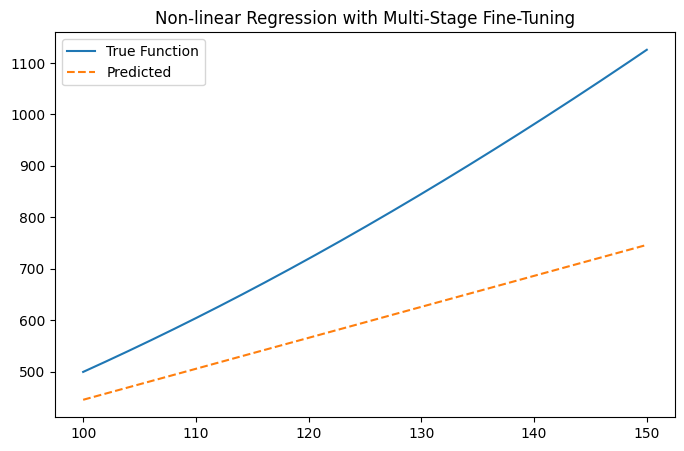

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ----- Non-linear Regression Model -----
class NonLinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

# ----- Training Function -----
def train(model, x, y, epochs=500, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
    return model

# ----- Non-linear Data Generator -----
def make_data(start, end, n=200):
    x = torch.linspace(start, end, n).unsqueeze(1)
    y = torch.sin(0.1*x) + 0.05 * x**2  # non-linear target
    return x, y

# ----- Stage 1: Small range -----
x1, y1 = make_data(0, 50)
model = NonLinearRegressor()
model = train(model, x1, y1, epochs=1000, lr=1e-3)

# ----- Stage 2: Fine-tune on larger range -----
x2, y2 = make_data(0, 100)
model = train(model, x2, y2, epochs=500, lr=5e-4)

# ----- Stage 3: Evaluate extrapolation -----
x_test, y_test = make_data(100, 150)
with torch.no_grad():
    y_pred = model(x_test)

# ----- Plot -----
plt.figure(figsize=(8,5))
plt.plot(x_test.numpy(), y_test.numpy(), label="True Function")
plt.plot(x_test.numpy(), y_pred.numpy(), label="Predicted", linestyle='--')
plt.legend()
plt.title("Non-linear Regression with Multi-Stage Fine-Tuning")
plt.show()


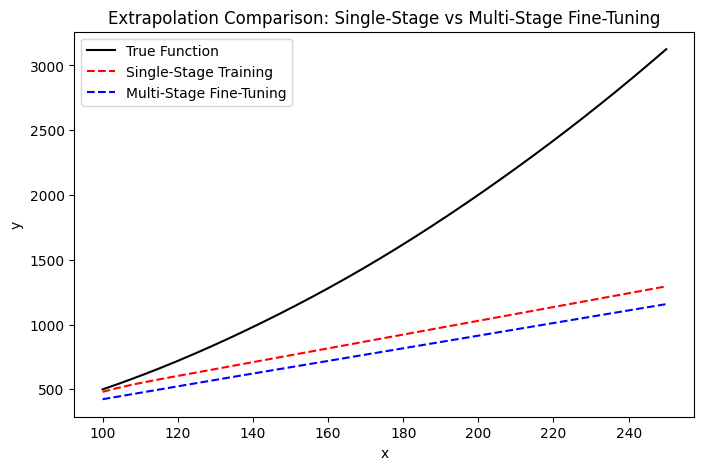

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ----- Non-linear Regression Model -----
class NonLinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

# ----- Training Function -----
def train(model, x, y, epochs=500, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
    return model

# ----- Data Generator -----
def make_data(start, end, n=200):
    x = torch.linspace(start, end, n).unsqueeze(1)
    y = torch.sin(0.1*x) + 0.05 * x**2
    return x, y

# ----- Stage 1: Small range -----
x_small, y_small = make_data(0, 100)

# --- Model trained only on small range ---
model_single = NonLinearRegressor()
model_single = train(model_single, x_small, y_small, epochs=1000, lr=1e-3)

# --- Model with multi-stage fine-tuning ---
model_multi = NonLinearRegressor()
# Stage 1: train on small range
x_small, y_small = make_data(0, 50)
model_multi = train(model_multi, x_small, y_small, epochs=500, lr=1e-3)
# Stage 2: fine-tune on larger range [0, 100]
x_large, y_large = make_data(50, 100)
model_multi = train(model_multi, x_large, y_large, epochs=500, lr=5e-4)

# ----- Test Range: extrapolation [100, 150] -----
x_test, y_test = make_data(100, 250)
with torch.no_grad():
    y_pred_single = model_single(x_test)
    y_pred_multi  = model_multi(x_test)

# ----- Plot Comparison -----
plt.figure(figsize=(8,5))
plt.plot(x_test.numpy(), y_test.numpy(), label="True Function", color='black')
plt.plot(x_test.numpy(), y_pred_single.numpy(), label="Single-Stage Training", linestyle='--', color='red')
plt.plot(x_test.numpy(), y_pred_multi.numpy(), label="Multi-Stage Fine-Tuning", linestyle='--', color='blue')
plt.legend()
plt.title("Extrapolation Comparison: Single-Stage vs Multi-Stage Fine-Tuning")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [3]:
# Simple Paxos single-value consensus (3 nodes)

class Acceptor:
    def __init__(self):
        self.promised_id = 0
        self.accepted_id = 0
        self.accepted_value = None

    def prepare(self, proposal_id):
        if proposal_id > self.promised_id:
            self.promised_id = proposal_id
            return True, self.accepted_id, self.accepted_value
        return False, self.accepted_id, self.accepted_value

    def accept(self, proposal_id, value):
        if proposal_id >= self.promised_id:
            self.promised_id = proposal_id
            self.accepted_id = proposal_id
            self.accepted_value = value
            return True
        return False

# Setup
acceptors = [Acceptor() for _ in range(3)]

# Proposer tries to propose "A" with proposal_id=1
proposal_id = 1
proposal_value = "A"

# Phase 1: Prepare
promises = [a.prepare(proposal_id)[0] for a in acceptors]
if promises.count(True) >= 2:  # Majority (quorum)
    # Phase 2: Accept
    accepts = [a.accept(proposal_id, proposal_value) for a in acceptors]
    if accepts.count(True) >= 2:
        print(f"Consensus achieved: value '{proposal_value}' accepted by majority")
    else:
        print("Accept phase failed: consensus not reached")
else:
    print("Prepare phase failed: not enough promises")

# Show final acceptor states
for i, a in enumerate(acceptors, 1):
    print(f"Acceptor {i}: accepted_id={a.accepted_id}, accepted_value={a.accepted_value}")


Consensus achieved: value 'A' accepted by majority
Acceptor 1: accepted_id=1, accepted_value=A
Acceptor 2: accepted_id=1, accepted_value=A
Acceptor 3: accepted_id=1, accepted_value=A
